<a href="https://colab.research.google.com/github/Bonkerzz2603/TH_deaplearn/blob/main/NguyenGiaKhang_THDeepLearn_tuan3_b1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tải và tiền xử lý dữ liệu CIFAR-10

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

#CIFAR-10 tensorflow
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Chuan hoa gt pixel ve doan [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"(X_train): {x_train.shape}")
print(f"(X_test): {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(X_train): (50000, 32, 32, 3)
(X_test): (10000, 32, 32, 3)


#Định nghĩa kiến trúc mạng Autoencoder


In [2]:
#(anh muu 32x32 voi 3 kenh RGB)
input_img = layers.Input(shape=(32, 32, 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.UpSampling2D((2, 2))(encoded)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)

decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

# Huấn luyện mô hình với dữ liệu đầu vào và đầu ra đều là chính nó (x_train)

In [3]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=15,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 454s 577ms/step - loss: 0.0071 - val_loss: 0.0037
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 426s 545ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 447s 551ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 440s 548ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 464s 577ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 427s 546ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 428s 547ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 447s 553ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 439s 550ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 441s 548ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 11/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 427s 546ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 12

#Trực quan hóa kết quả

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step


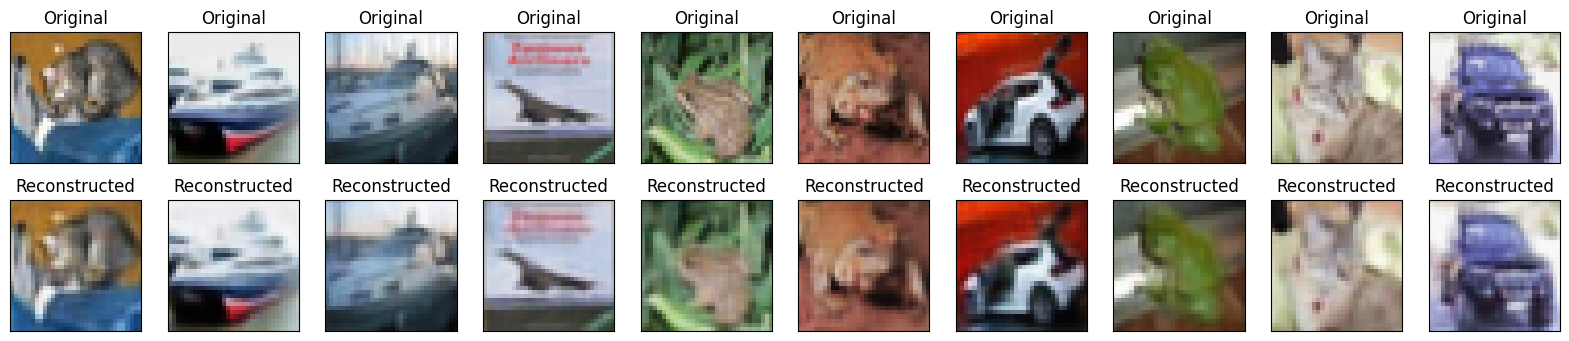

In [5]:
# Du doa thu nghie
decoded_imgs = autoencoder.predict(x_test)

# Cac nhan hien thi tuong ung cua tap CIFAR-10
label_descriptions = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Ve bieu do
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Ve anh sau khi di qua Autoencoder
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()